# Budgeted MLMC vs MLQMC

## Imports

In [1]:
import numpy as np
import scipy.stats
import os

In [2]:
import seaborn as sns 
import matplotlib 
from matplotlib import pyplot,cycler
import pandas as pd
pyplot.style.use("seaborn-v0_8-whitegrid")
COLORS = ["xkcd:"+color[:-1] for color in pd.read_csv("./xkcd_colors_custom.txt",comment="#",header=None).iloc[:,0].tolist()][::-1]
pyplot.rcParams['axes.prop_cycle'] = cycler(color=COLORS)
#pyplot.rcParams['axes.prop_cycle'] = matplotlib.cycler(color=COLORS)
WIDTH = 2*(500/72)
LW = 3
alpha = .2

In [3]:
from IPython.display import display, HTML
display(HTML("<style>pre { white-space: pre !important; }</style>"))

## Load Data

In [4]:
ALPHA = .95
R = 8
dataroots = [
    # "./budgeted_comparison_data/SL/d32/Sumxex/",
    # "./budgeted_comparison_data/SL/d32/MC2/",
    # "./budgeted_comparison_data/SL/d32/Ridge_Jump_Equal_Weights/",
    # "./budgeted_comparison_data/SL/d32/Ridge_PL_Equal_Weights/",
    # "./budgeted_comparison_data/SL/d32/Ridge_Kink_Equal_Weights/",
    # "./budgeted_comparison_data/SL/d32/Ridge_Finance_Equal_Weights/",
    # "./budgeted_comparison_data/SL/d32/Ridge_Smooth_Equal_Weights/",
    # "./budgeted_comparison_data/SL/d32/Ridge_JSU_Equal_Weights/",
    # "./budgeted_comparison_data/SL/d32/Ridge_Jump_Sparse_Weights/",
    # "./budgeted_comparison_data/SL/d32/Ridge_PL_Sparse_Weights/",
    # "./budgeted_comparison_data/SL/d32/Ridge_Kink_Sparse_Weights/",
    # "./budgeted_comparison_data/SL/d32/Ridge_Finance_Sparse_Weights/",
    # "./budgeted_comparison_data/SL/d32/Ridge_Smooth_Sparse_Weights/",
    # "./budgeted_comparison_data/SL/d32/Ridge_JSU_Sparse_Weights/",
    # "./budgeted_comparison_data/SL/d32/Genz_Oscillatory_1/",
    # "./budgeted_comparison_data/SL/d32/Genz_Oscillatory_2/",
    # "./budgeted_comparison_data/SL/d32/Genz_Oscillatory_3/",
    # "./budgeted_comparison_data/SL/d32/Genz_Corner-Peak_1/",
    # "./budgeted_comparison_data/SL/d32/Genz_Corner-Peak_2/",
    # "./budgeted_comparison_data/SL/d32/Genz_Corner-Peak_3/",
    "./budgeted_comparison_data/ML/Asian_Option/",
    "./budgeted_comparison_data/ML/Lookback_Option/",
    "./budgeted_comparison_data/ML/Elliptic_PDE/",
    # "./budgeted_comparison_data/Darcy_Flow_PDE_2D.NEW/",
]
problem_names = []
dimensions = []
num_levels = []
true_solutions = []
max_budgets = []
costs = []
means = []
std_errors = []
samples_per_level = []
true_errors = []
trials = []
ci_half_widths = []
for i,dr in enumerate(dataroots):
    data = np.load(dr+"data.npy",allow_pickle=True)[()]
    problem_names.append(data["problem_name"])
    if i>0: assert names==data["names"]
    names = data["names"]
    dimensions.append(data["dimension"])
    num_levels.append(data["num_levels"])
    true_solutions.append(data["true_solution"])
    max_budgets.append(data["max_budgets"])
    costs.append(data["costs"])
    means.append(data["means"])
    samples_per_level.append(data["samples_per_level"])
    true_errors.append(data["true_errors"])
    trials.append(data["trials"])
    std_error = data["std_errors"]
    std_errors.append(std_error)
    ci_half_width = np.nan*np.ones_like(std_error)
    for i,name in enumerate(names):
        if name=="MC":
            ci_half_width[i] = scipy.stats.norm.ppf((1+ALPHA)/2)*std_error[i]
        elif name[:5]=="GPQMC":
            # GPs require computing variance which has numerical errors when on the order of machine precision
            ci_half_width[i] = scipy.stats.norm.ppf((1+ALPHA)/2)*std_error[i]
            # ci_half_width[i] = np.maximum(np.sqrt(np.finfo(np.float64).eps),ci_half_width[i])
        elif name[:4]=="RQMC": # make sure to change R at the top of the script if not using 8 replications
            ci_half_width[i] = scipy.stats.t.ppf((1+ALPHA)/2,df=R-1)*std_error[i]
        else:
            assert False, name
    # ci_half_width[ci_half_width<=0] = np.nan
    ci_half_widths.append(ci_half_width)
def find_common_substring(los):
    c = 0
    while True:
        if c==len(los[0]): break
        _s = los[0][c]
        for i in range(1,len(los)):
            if _s!=los[i][c]:
                return los[0][:c]
        c += 1 
    return los[0][:c]
dataroot = find_common_substring(dataroots)
problem_names = np.stack(problem_names,axis=0)
num_levels = np.stack(num_levels,axis=0)
true_solutions = np.stack(true_solutions,axis=0)
trials = np.stack(trials,axis=0)
names = [name.strip() for name in names]
print("dataroot = %s"%dataroot)
print("problem_names = %s"%str(problem_names))
print("names = %s"%str(names))
print("len(dimensions) = %s"%len(dimensions))
print("num_levels.shape = %s"%str(num_levels.shape))
print("true_solutions.shape = %s"%str(true_solutions.shape))
print("len(max_budgets) = %s"%len(max_budgets))
print("len(costs) = %s"%len(costs))
print("len(means) = %s"%len(means))
print("lenstd_errors) = %s"%len(std_errors))
print("lensamples_per_level) = %s"%len(samples_per_level))
print("lentrue_errors) = %s"%len(true_errors))
print("trials.shape = %s"%str(trials.shape))
print("len(ci_half_widths) = %s"%len(ci_half_widths))    

dataroot = ./budgeted_comparison_data/ML/
problem_names = ['Asian Option' 'Lookback Option' 'Elliptic PDE']
names = ['MC', 'RQMC Lat', 'RQMC Net', 'GPQMC Lat', 'GPQMC Net']
len(dimensions) = 3
num_levels.shape = (3,)
true_solutions.shape = (3,)
len(max_budgets) = 3
len(costs) = 3
len(means) = 3
lenstd_errors) = 3
lensamples_per_level) = 3
lentrue_errors) = 3
trials.shape = (3,)
len(ci_half_widths) = 3


## Convergence by Error

/Users/agsorok/miniconda3/envs/mlqmcpy/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


./budgeted_comparison_data/ML/convergence_by_error.pdf


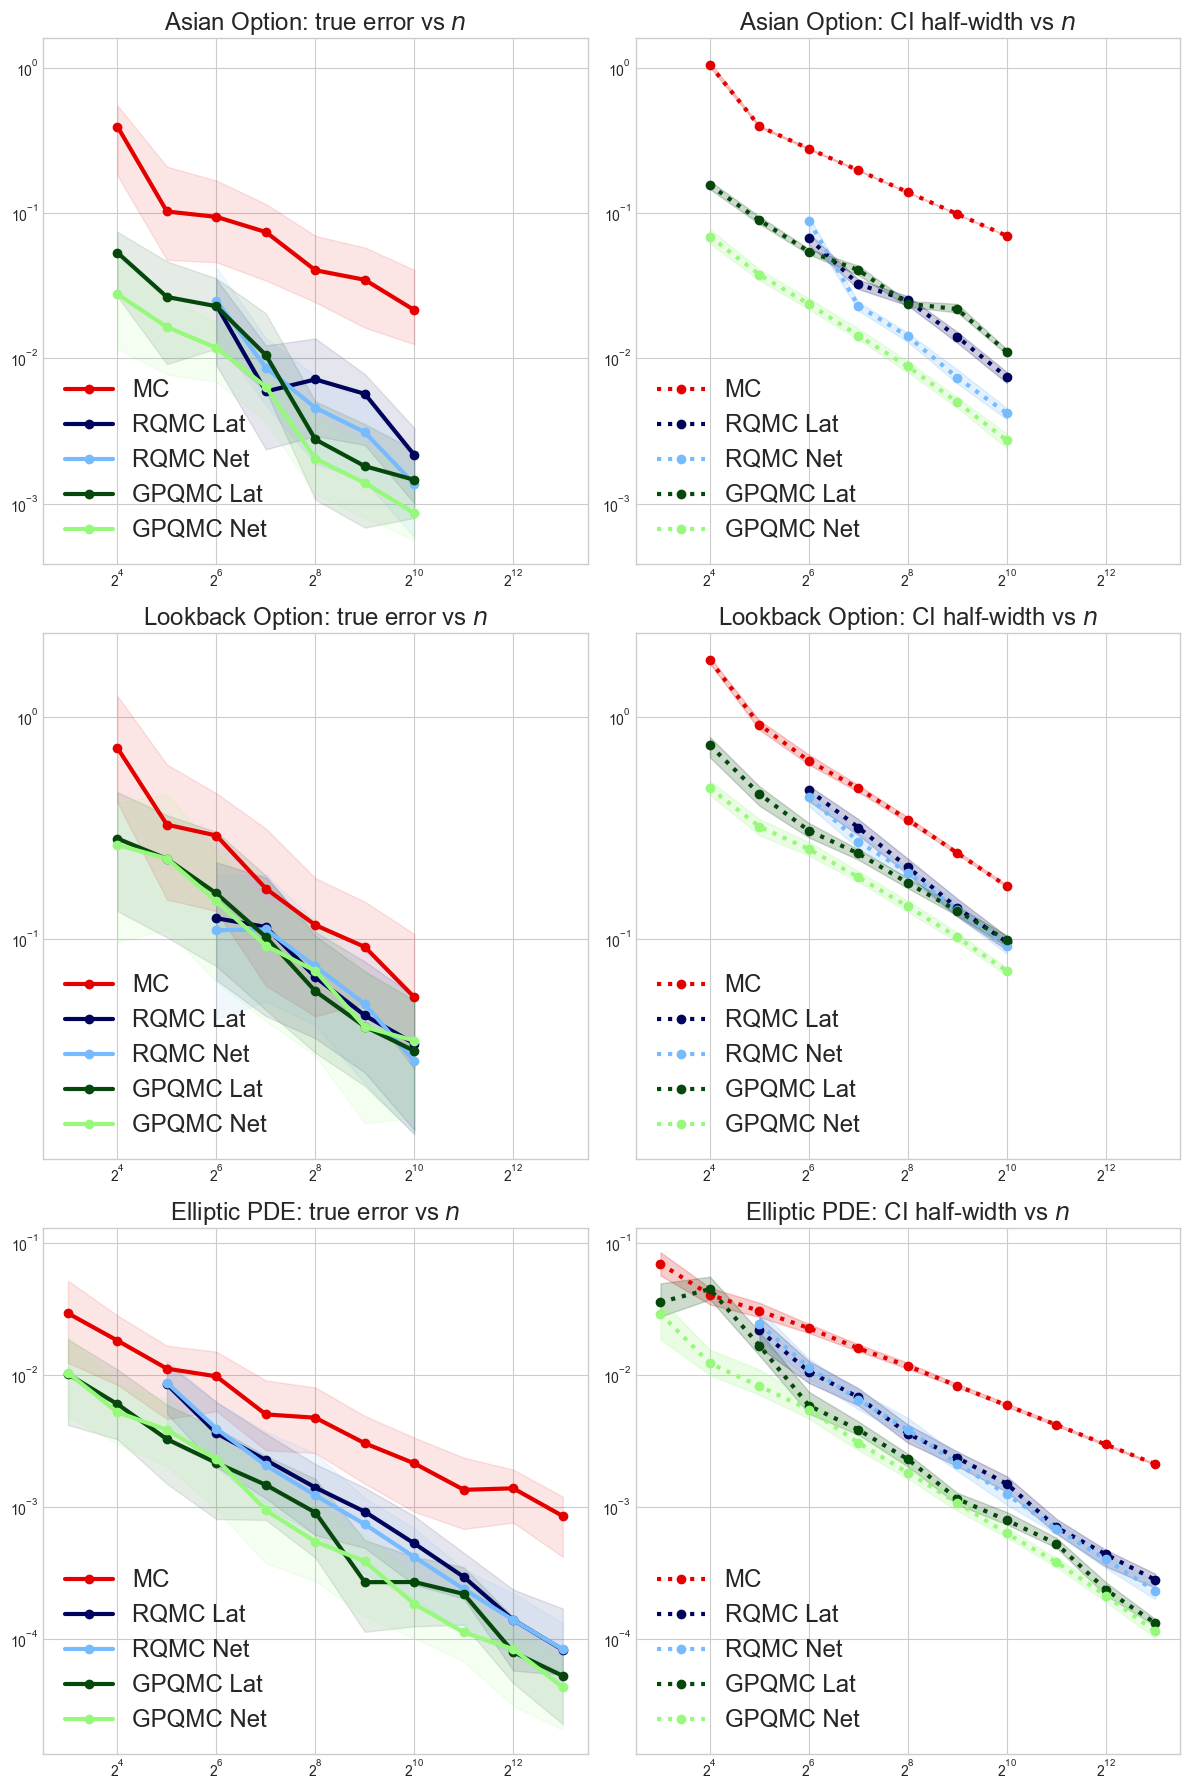

In [5]:
nrows = len(problem_names)
ncols = 2 
fig,ax = pyplot.subplots(nrows=nrows,ncols=ncols,figsize=(6*ncols,6*nrows),sharey="row",sharex=True)
ax = np.atleast_1d(ax).reshape(nrows,ncols)
for r in range(nrows):
    for i in range(len(names)):
        for j,(vals,linestyle,alpha) in enumerate(zip([true_errors[r][i],ci_half_widths[r][i]],[None,'dotted'],[.1,.2])):
            q_low = np.nanquantile(vals,.25,axis=1)
            q_med = np.nanquantile(vals,.5,axis=1)
            q_high = np.nanquantile(vals,.75,axis=1)
            label = names[i] #if r==j==0 else None
            ax[r,j].plot(max_budgets[r],q_med,marker='o',linestyle=linestyle,label=label,linewidth=LW,alpha=1,color=COLORS[i])
            ax[r,j].fill_between(max_budgets[r],q_low,q_high,alpha=alpha,color=COLORS[i])
            ax[r,j].legend(frameon=False,fontsize="xx-large",loc="lower left")
    ax[r,0].set_title(r"%s: true error vs $n$"%problem_names[r],fontsize="xx-large")
    ax[r,1].set_title(r"%s: CI half-width vs $n$"%problem_names[r],fontsize="xx-large")
    for j in range(2):
        ax[r,j].set_yscale("log",base=10)
        ax[r,j].set_xscale("log",base=2)
        ax[r,j].tick_params(labelleft=True,labelbottom=True)
# fig.suptitle(r"Error vs budget $n$",fontsize="xx-large")
# fig.legend(frameon=False,fontsize="x-large",bbox_to_anchor=(.9,.95),ncols=5)
fig.tight_layout()
figpath = dataroot+"convergence_by_error.pdf"
print(figpath)
fig.savefig(figpath,transparent=True,bbox_inches="tight")

## Convergence by Method

/Users/agsorok/miniconda3/envs/mlqmcpy/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


./budgeted_comparison_data/ML/convergence_by_method.pdf


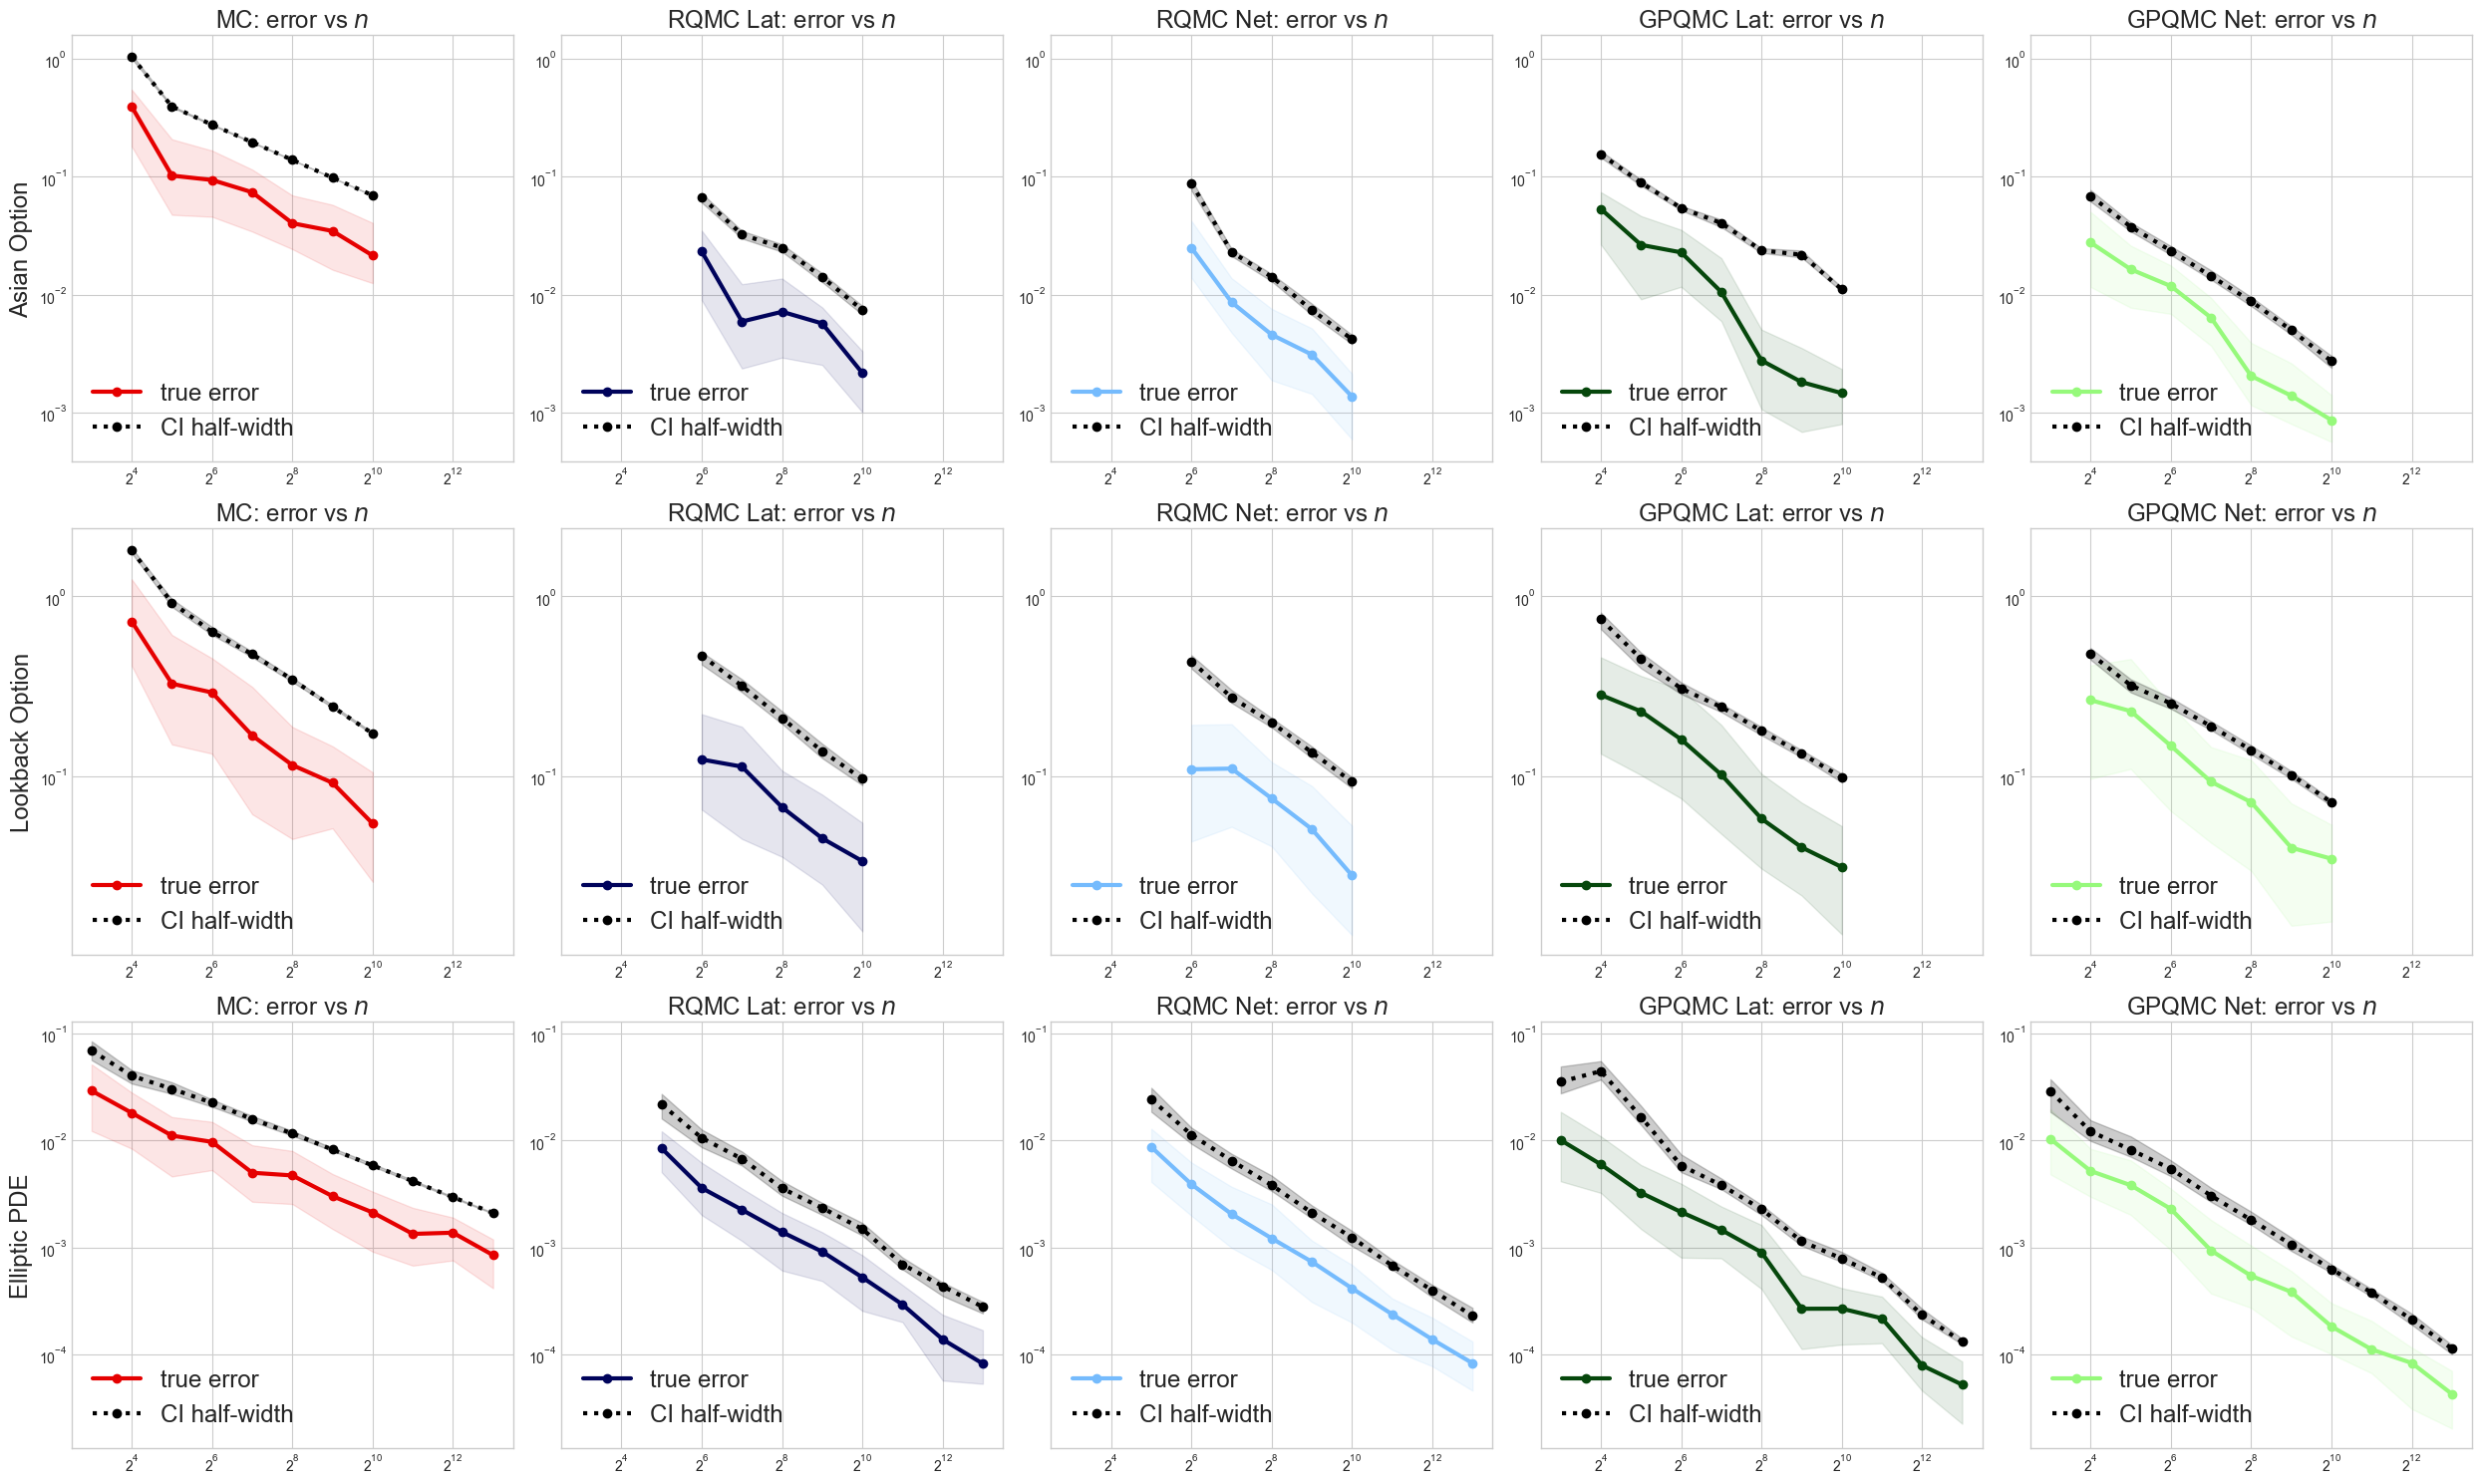

In [6]:
ncols = len(names)
nrows = len(problem_names)
fig,ax = pyplot.subplots(nrows=nrows,ncols=ncols,figsize=(5*ncols,5*nrows),sharey="row",sharex=True)
ax = np.atleast_1d(ax).reshape((nrows,ncols))
for r in range(nrows):
    for i in range(ncols):
        for j,(error_metric,vals,linestyle,alpha,color) in enumerate(zip(["true error","CI half-width"],[true_errors[r][i],ci_half_widths[r][i]],[None,'dotted'],[.1,.2],[COLORS[i],'k'])):
            q_low = np.nanquantile(vals,.25,axis=1)
            q_med = np.nanquantile(vals,.5,axis=1)
            q_high = np.nanquantile(vals,.75,axis=1)
            ax[r,i].plot(max_budgets[r],q_med,marker='o',linestyle=linestyle,label=error_metric,linewidth=LW,alpha=1,color=color)
            ax[r,i].fill_between(max_budgets[r],q_low,q_high,alpha=alpha,color=color)
            ax[r,i].set_title(r"%s: error vs $n$"%names[i],fontsize="xx-large")
            ax[r,i].legend(frameon=False,fontsize="xx-large",loc="lower left")
            ax[r,i].tick_params(labelleft=True,labelbottom=True)
        ax[r,i].set_yscale("log",base=10)
        ax[r,i].set_xscale("log",base=2)
    ax[r,0].set_ylabel(problem_names[r],fontsize="xx-large")
fig.tight_layout()
# fig.suptitle(r"Error vs budget $n$",fontsize="xx-large")
figpath = dataroot+"convergence_by_method.pdf"
print(figpath)
fig.savefig(figpath,transparent=True,bbox_inches="tight")

## Error Scatters

./budgeted_comparison_data/ML/error_scatters.pdf


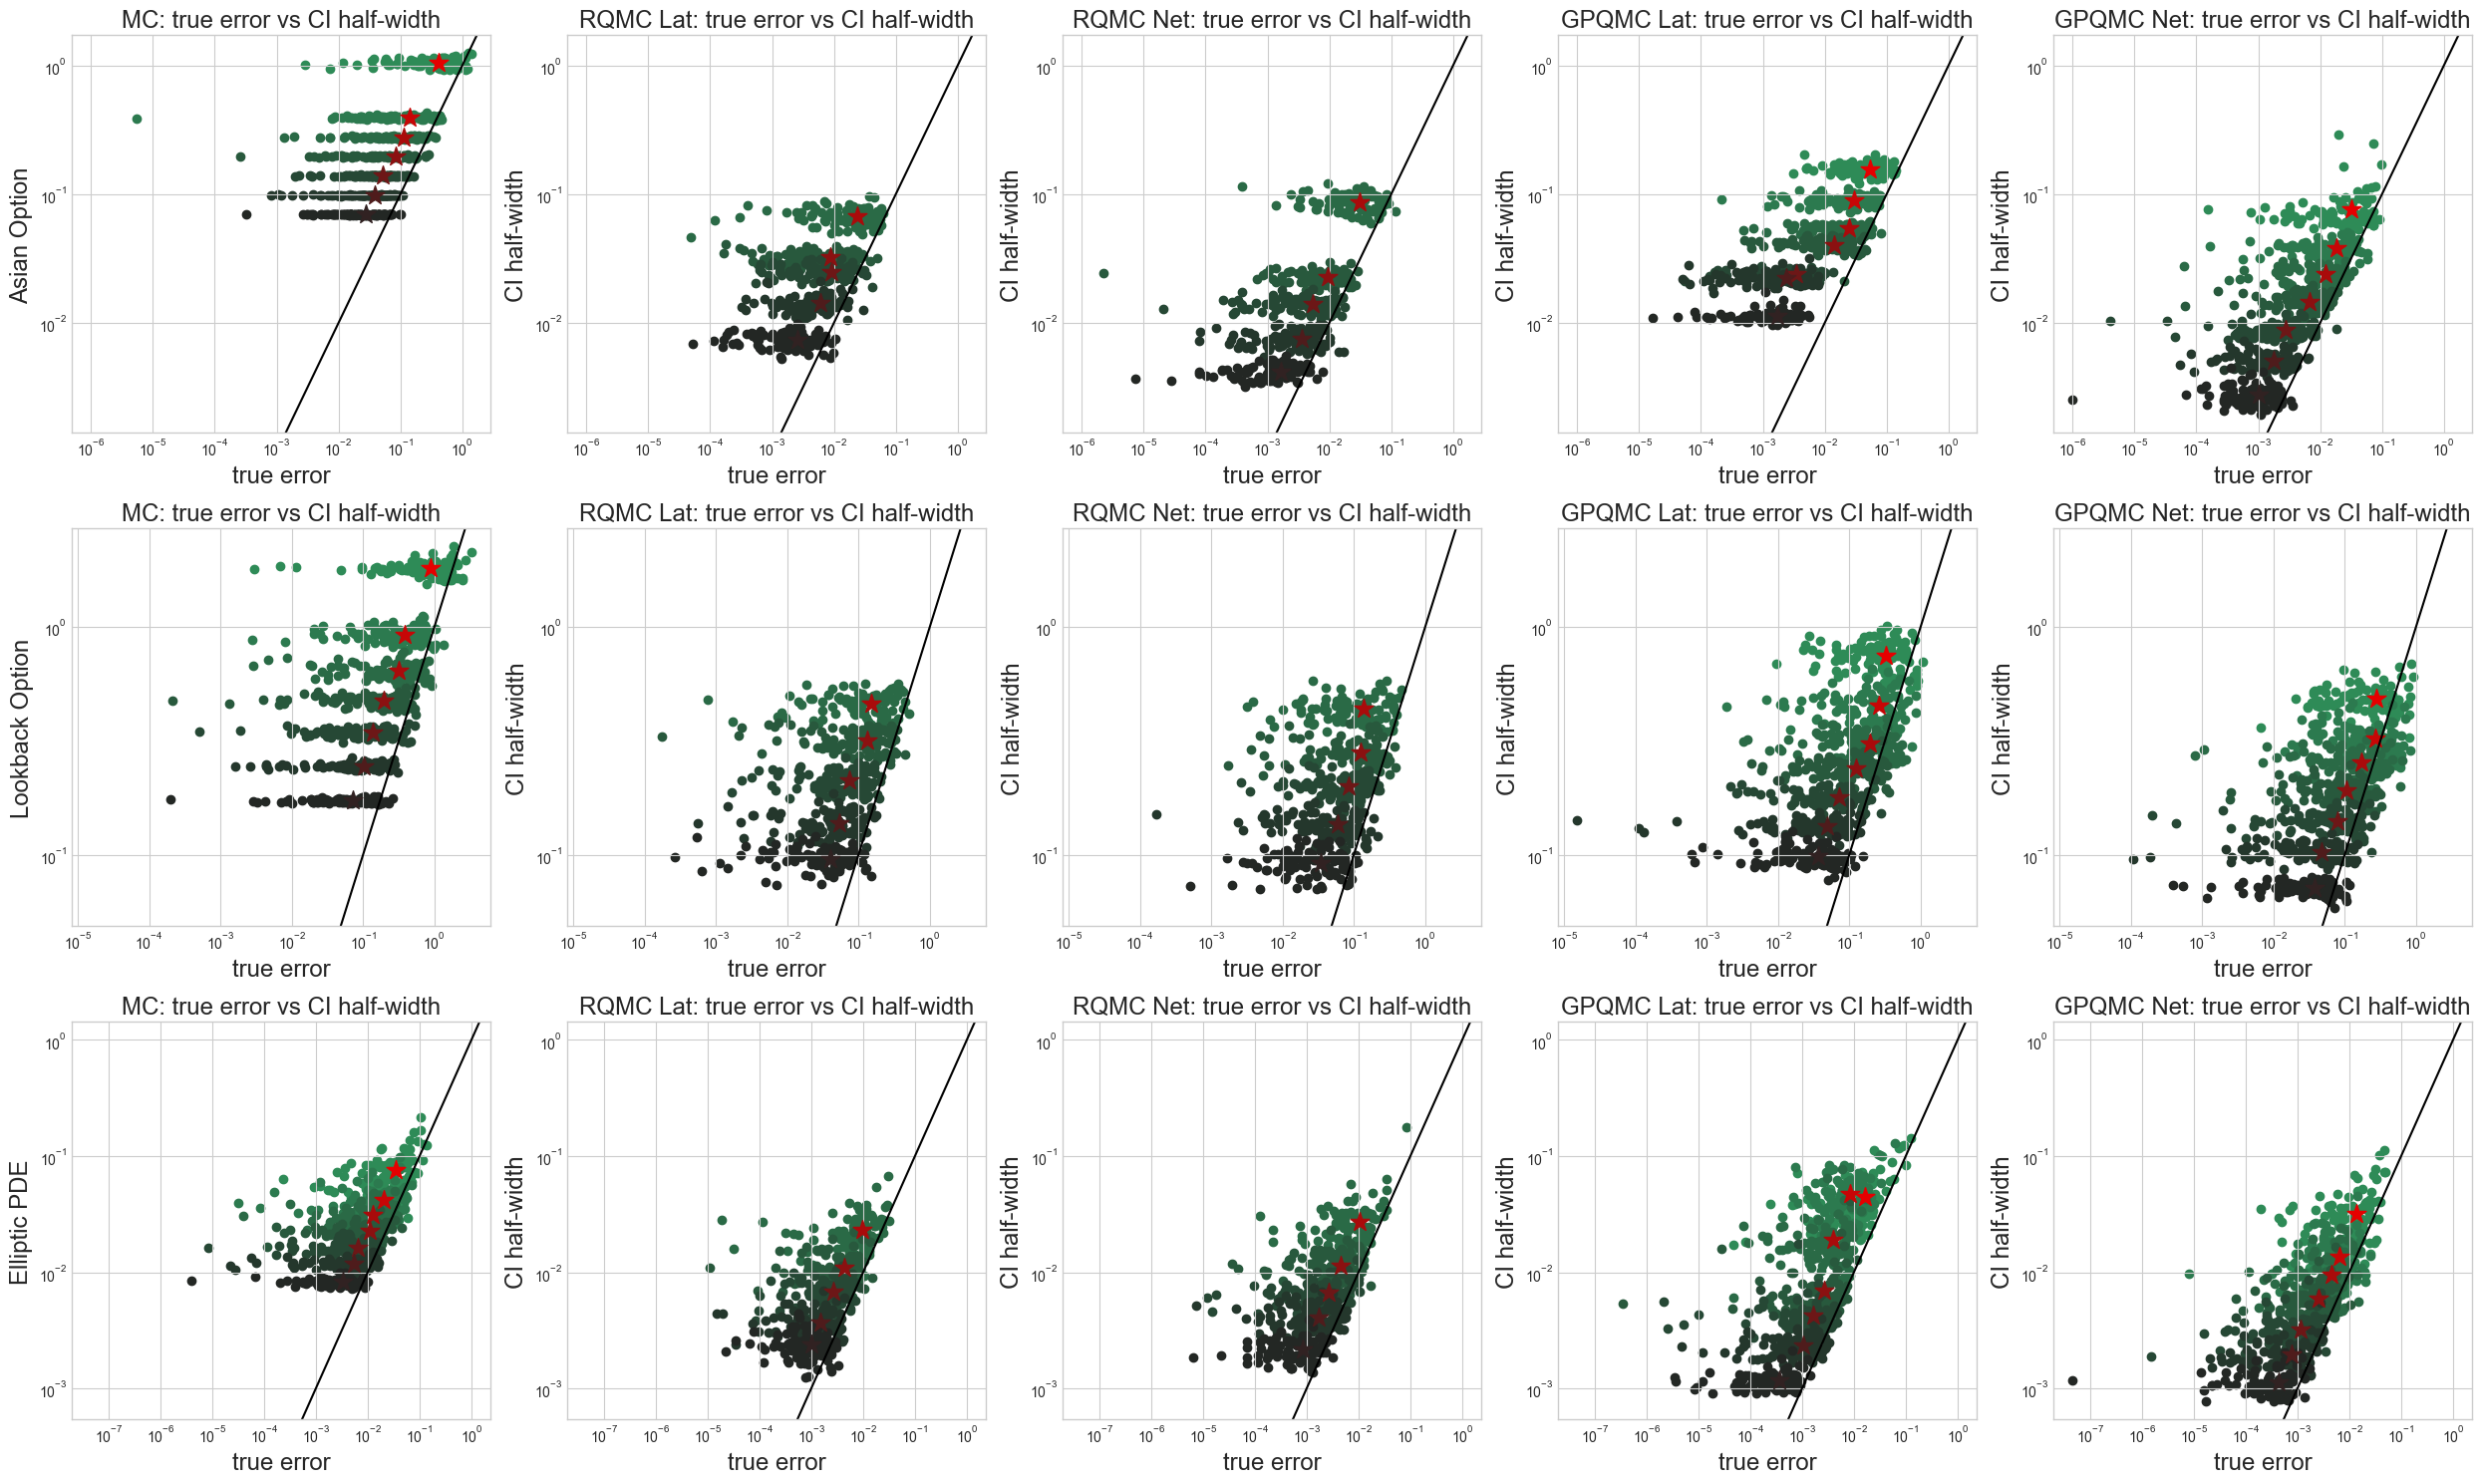

In [7]:
palette_pts = sns.dark_palette("seagreen",n_colors=len(max_budgets[0]),reverse=True) # https://seaborn.pydata.org/generated/seaborn.cubehelix_palette.html
palette_means = sns.dark_palette("xkcd:red",n_colors=len(max_budgets[0]),reverse=True)
nrows = len(problem_names)
ncols = len(names)
fig,ax = pyplot.subplots(nrows=nrows,ncols=ncols,figsize=(5*ncols,5*nrows),sharex="row",sharey="row")
ax = np.atleast_1d(ax).reshape((nrows,ncols))
for i in range(nrows):
    for j in range(ncols):
        for k in range(len(max_budgets[0])):
            ax[i,j].scatter(true_errors[i][j,k],ci_half_widths[i][j,k],label=name,color=palette_pts[k],zorder=0)
            ax[i,j].scatter(true_errors[i][j,k].mean(),ci_half_widths[i][j,k].mean(),color=palette_means[k],s=200,marker='*')
        ax[i,j].axline(xy1=(0,0),xy2=(1,1),color="k")
        ax[i,j].tick_params(labelbottom=True,labelleft=True)
        ax[i,j].set_xscale("log",base=10)
        ax[i,j].set_yscale("log",base=10)
        ax[i,j].set_xlabel("true error",fontsize="xx-large")
        ax[i,j].set_ylabel("CI half-width",fontsize="xx-large")
        ax[i,j].set_title("%s: true error vs CI half-width"%names[j],fontsize="xx-large")
    ax[i,0].set_ylabel(problem_names[i],fontsize="xx-large")
# fig.suptitle("true error vs CI half-width",fontsize='xx-large')
fig.tight_layout()
figpath = dataroot+"error_scatters.pdf"
print(figpath)
fig.savefig(figpath,transparent=True,bbox_inches="tight")

## Densities

./budgeted_comparison_data/ML/densities.pdf


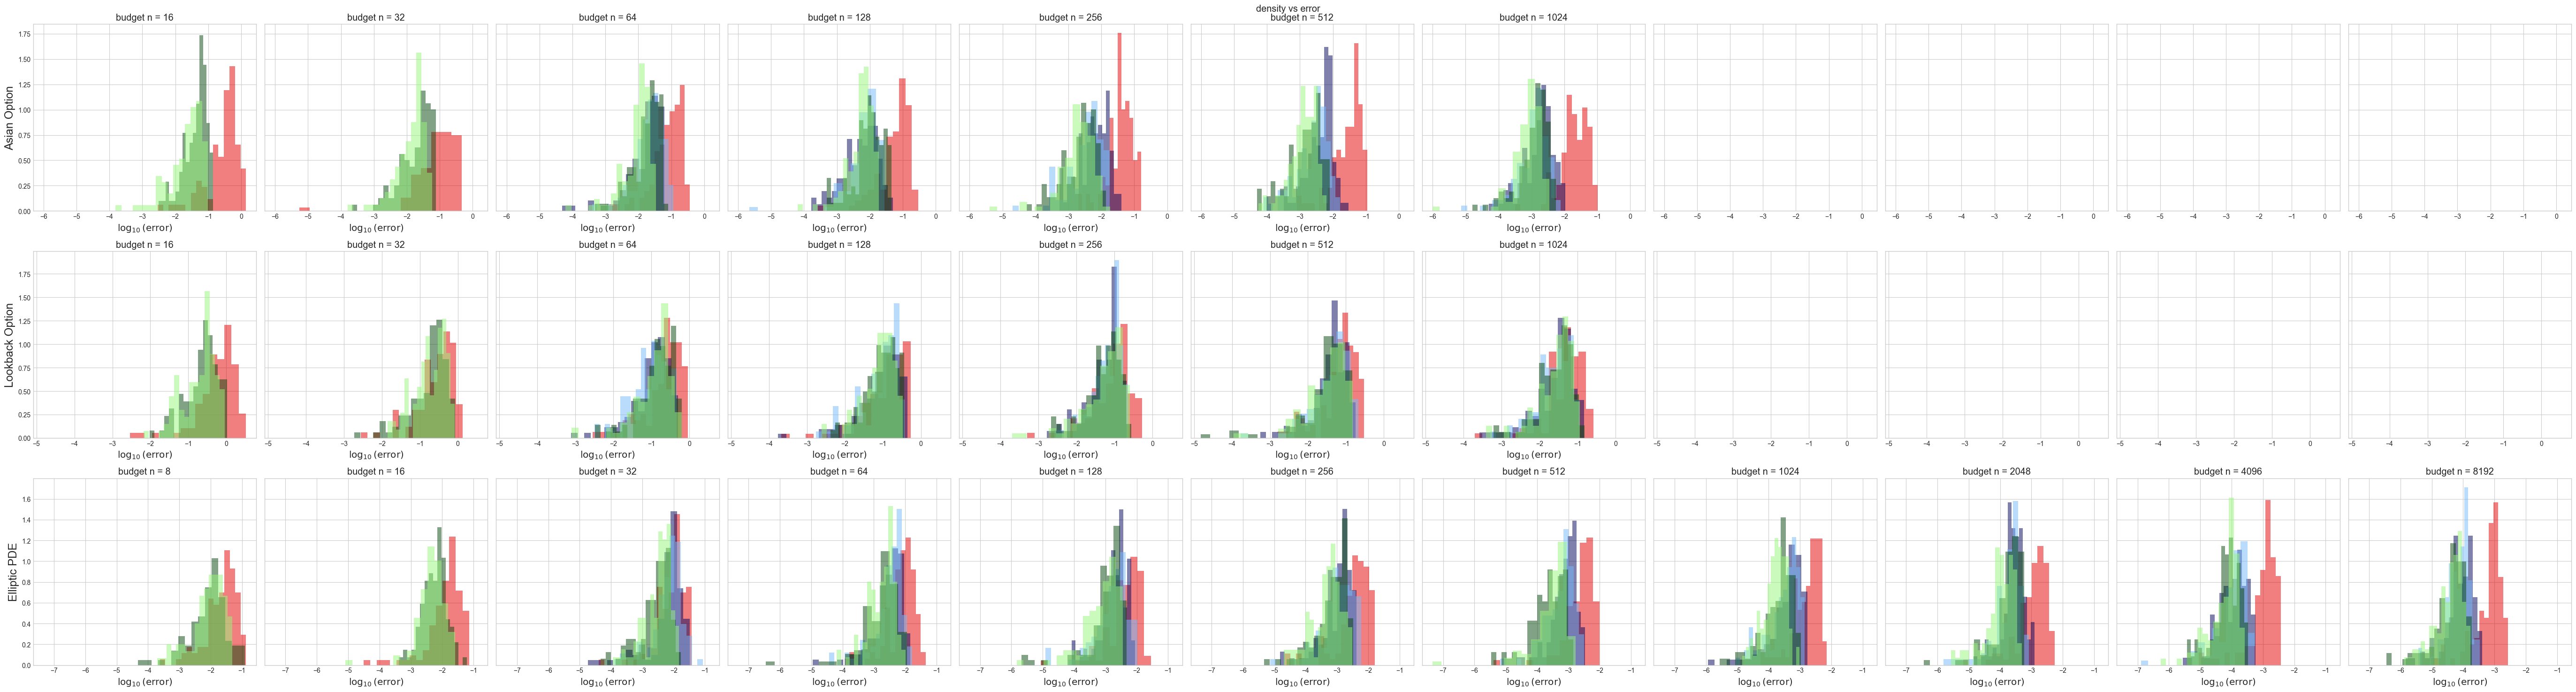

In [8]:
nrows = len(problem_names)
ncols = max([len(max_budgets[i]) for i in range(len(max_budgets))])
EPS = np.finfo(true_errors[0].dtype).eps
fig,ax = pyplot.subplots(nrows=nrows,ncols=ncols,figsize=(ncols*5,nrows*5),sharex="row",sharey="row")
ax = np.atleast_1d(ax).reshape(nrows,ncols)
for i in range(nrows):
    for j in range(len(max_budgets[i])):
        for k in range(len(names)):
            vals = true_errors[i][k,j]
            if np.isnan(vals).all(): continue
            ax[i,j].hist(np.log10(np.maximum(EPS,vals)),label=name,density=True,bins=16,alpha=.5,color=COLORS[k]) 
        ax[i,j].set_title(r"budget n = %d"%max_budgets[i][j],fontsize="x-large")
        ax[i,j].set_xlabel(r"$\log_{10}(\mathrm{error})$",fontsize="x-large")
    ax[i,0].set_ylabel(problem_names[i],fontsize="xx-large")
fig.suptitle(r"density vs error",fontsize="x-large")
fig.tight_layout()
figpath = dataroot+"densities.pdf"
print(dataroot+"densities.pdf")
fig.savefig(figpath,transparent=True,bbox_inches="tight")

## Sample Allocation

./budgeted_comparison_data/ML/sample_allocation.pdf


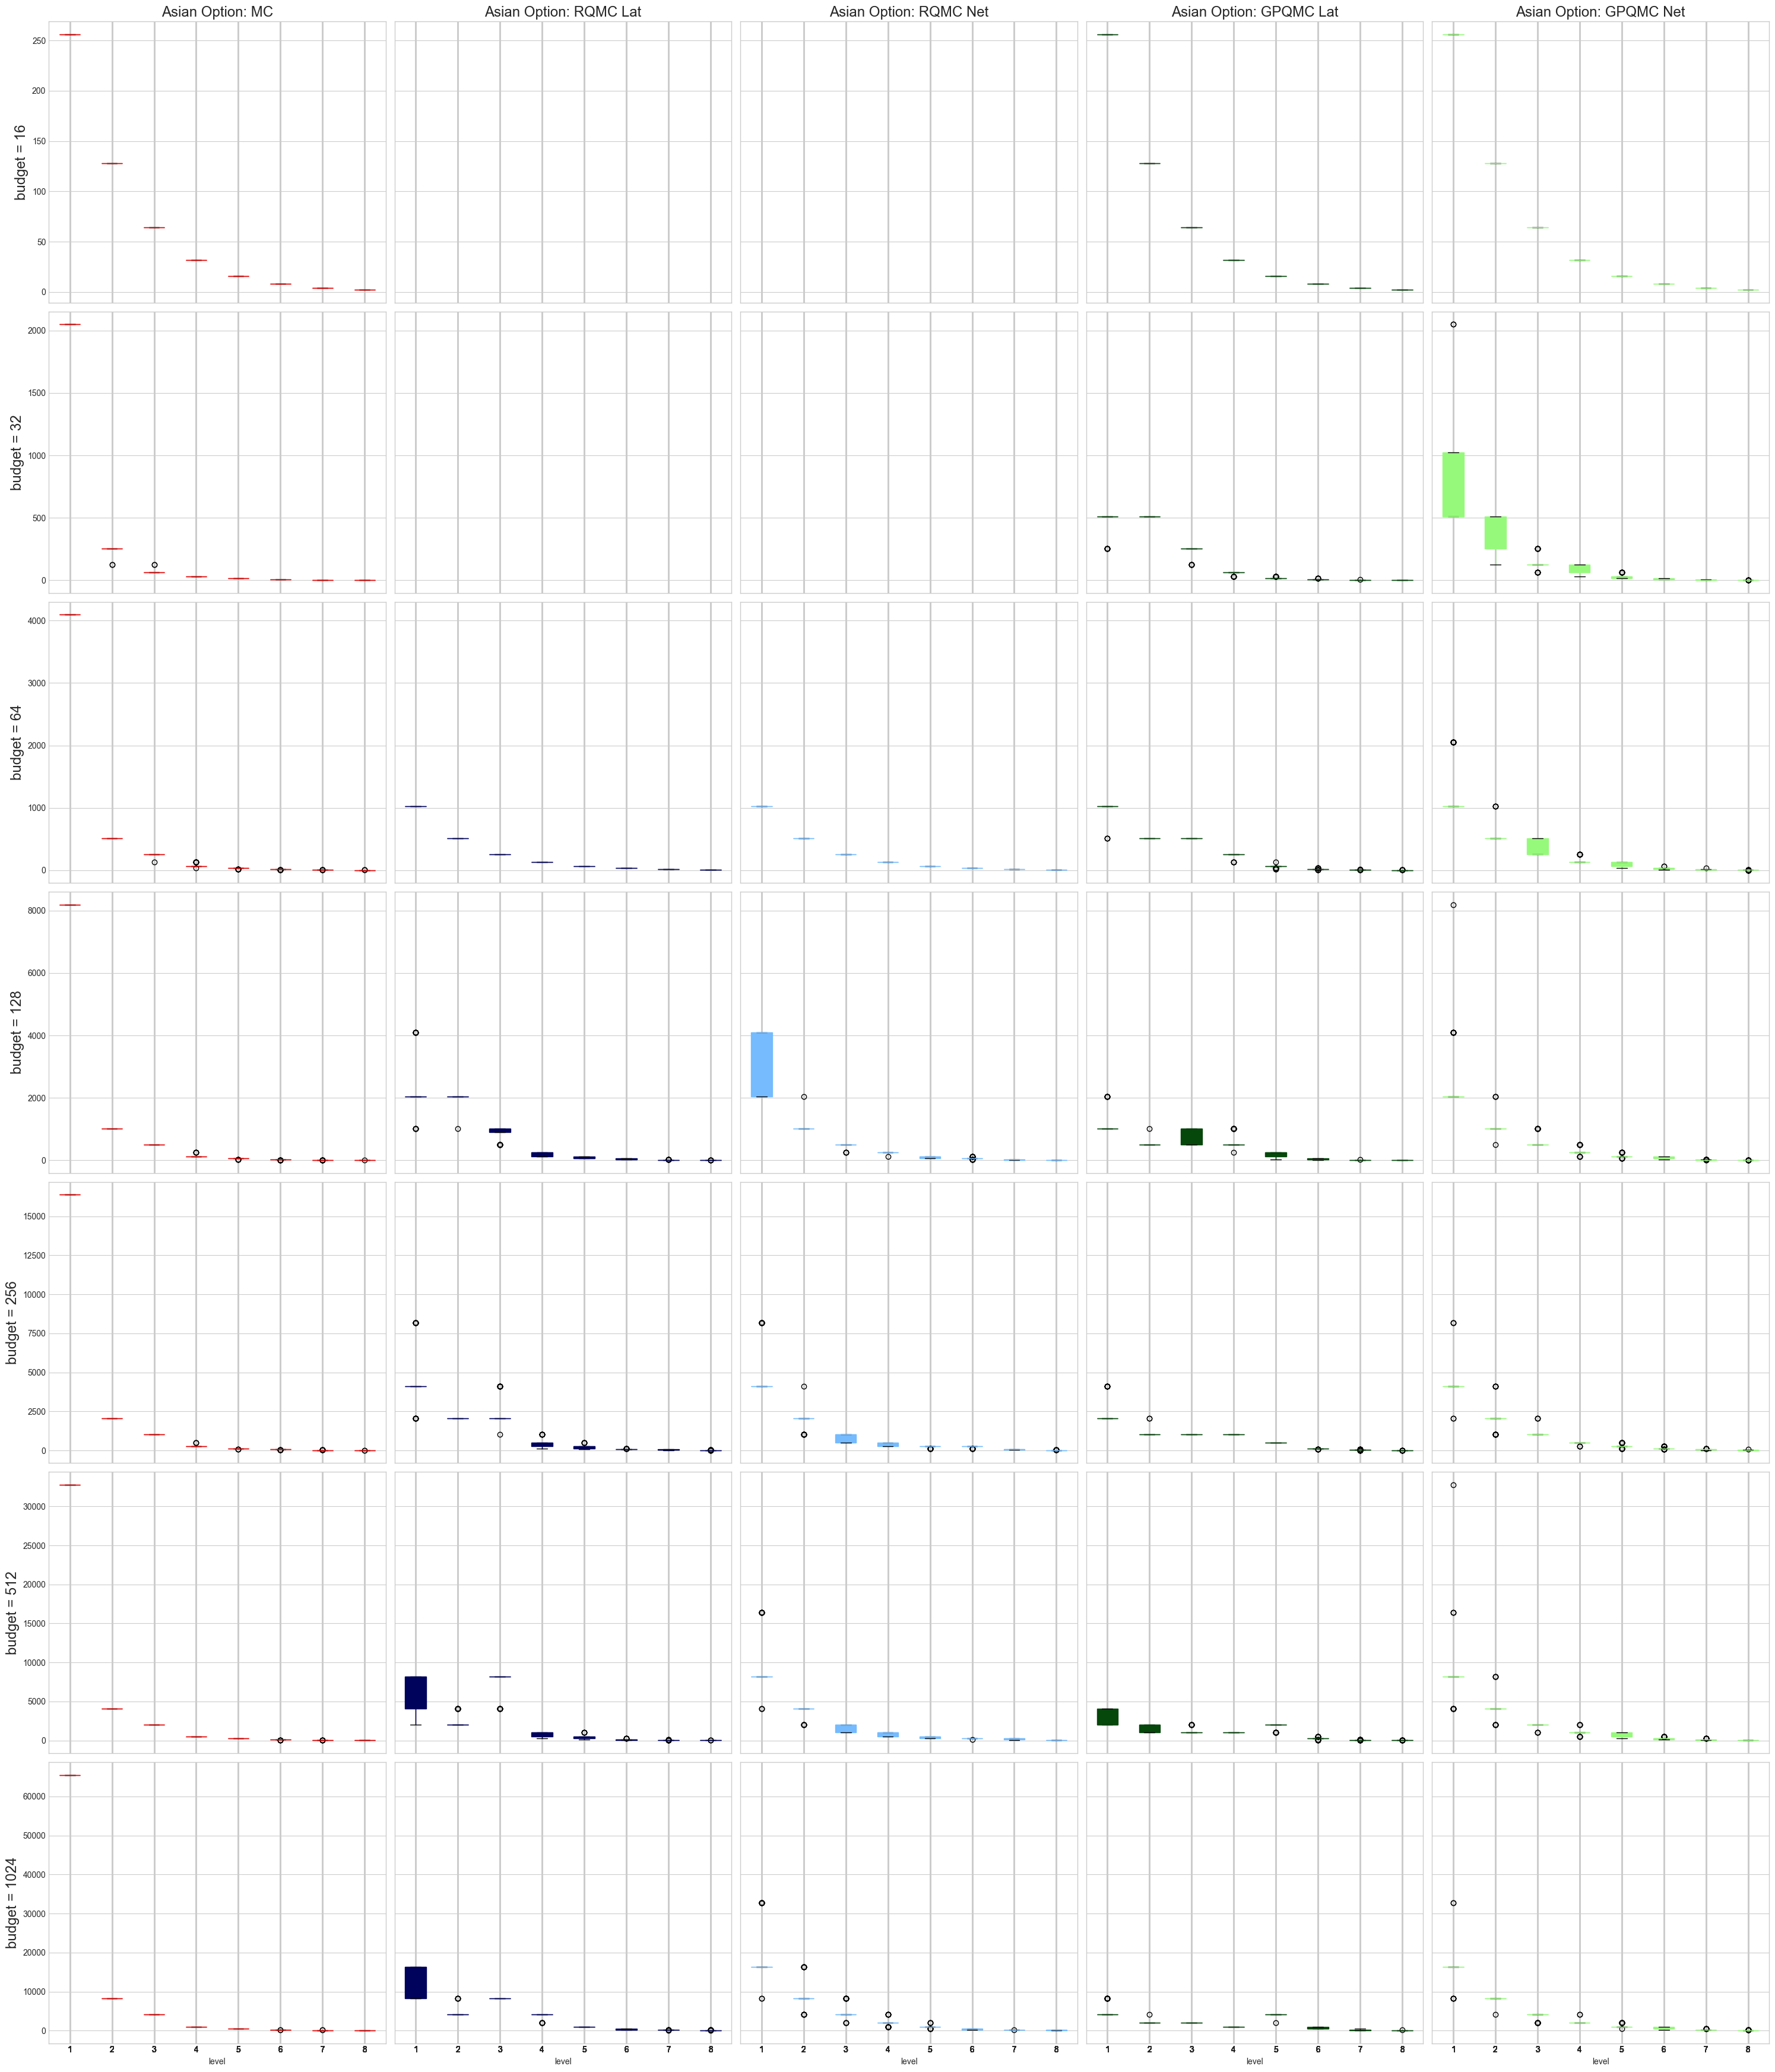

In [9]:
pidx = 0
nrows = len(max_budgets[pidx])
ncols = len(names)
fig,ax = pyplot.subplots(nrows=nrows,ncols=ncols,figsize=(6*ncols,5*nrows),sharey="row",sharex=True)
for i in range(nrows):
    for j in range(ncols):
        bplot = ax[i,j].boxplot(samples_per_level[pidx][j,i,:,:],orientation="vertical",label=names[j],patch_artist=True,notch=False);
        for _attr in ['boxes','means']:
            for patch in bplot[_attr]: patch.set_facecolor(COLORS[j])
        for _attr in ['medians','fliers','whiskers','medians','means','boxes']:
            for patch in bplot[_attr]: patch.set_color(COLORS[j])
    ax[i,0].set_ylabel("budget = %d"%max_budgets[pidx][i],fontsize="xx-large")
for j in range(ncols):
    ax[0,j].set_title("%s: %s"%(problem_names[pidx],names[j]),fontsize="xx-large")
    ax[-1,j].set_xlabel("level")
# fig.suptitle(r"%s"%problem_names[pidx],fontsize="xx-large")
fig.tight_layout()
figpath = dataroot+"sample_allocation.pdf"
print(figpath)
fig.savefig(figpath,transparent=True,bbox_inches="tight")